importing all the necessary libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

loading the data in the jupyter notebook

In [5]:
data = pd.read_csv("../data/raw_data.csv")

performing simple checks before data cleaning  

In [6]:
print("shape of the dataset:", data.shape)

shape of the dataset: (1100, 7)


In [7]:
print("data types of the dataset:\n", data.dtypes)

data types of the dataset:
 Building Type              str
Square Footage           int64
Number of Occupants      int64
Appliances Used          int64
Average Temperature    float64
Day of Week                str
Energy Consumption     float64
dtype: object


In [8]:
print("data information:\n ")
data.describe()

data information:
 


,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Energy Consumption
count,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,25500.527273,48.268182,25.730000,22.559745,4168.191273
std,14236.955632,29.127624,14.116209,7.122357,924.278723
min,560.000000,1.000000,1.000000,10.050000,1683.950000
25%,13203.750000,22.000000,13.000000,16.365000,3510.460000
50%,25785.500000,47.000000,26.000000,22.810000,4189.690000
75%,37536.750000,73.000000,38.000000,28.760000,4859.510000
max,49997.000000,99.000000,49.000000,34.990000,6530.600000


In [9]:
print("information about the dataset:\n ")
data.info()

information about the dataset:
 
<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Building Type        1100 non-null   str    
 1   Square Footage       1100 non-null   int64  
 2   Number of Occupants  1100 non-null   int64  
 3   Appliances Used      1100 non-null   int64  
 4   Average Temperature  1100 non-null   float64
 5   Day of Week          1100 non-null   str    
 6   Energy Consumption   1100 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 60.3 KB


In [10]:
print("checking for duplicates in the dataset:\n ")
data.duplicated().sum()

checking for duplicates in the dataset:
 


np.int64(0)

In [11]:
print("checking for null values in the dataset:\n ")
data.isnull().sum()

checking for null values in the dataset:
 


Building Type          0
Square Footage         0
Number of Occupants    0
Appliances Used        0
Average Temperature    0
Day of Week            0
Energy Consumption     0
dtype: int64

In [12]:
data.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17


In [13]:
data.tail()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
1095,Commercial,1161,81,11,15.45,Weekend,3010.81
1096,Residential,37943,50,23,21.73,Weekend,4248.49
1097,Commercial,1558,27,29,16.86,Weekend,2843.60
1098,Industrial,2145,56,12,11.77,Weekend,3348.39
1099,Residential,42414,72,24,29.62,Weekday,4722.59


PERFROMING EDA(exploratory data analysis) ON THE DATASET!!

univariate analysis

([0, 1], [Text(0, 0, 'Weekday'), Text(1, 0, 'Weekend')])

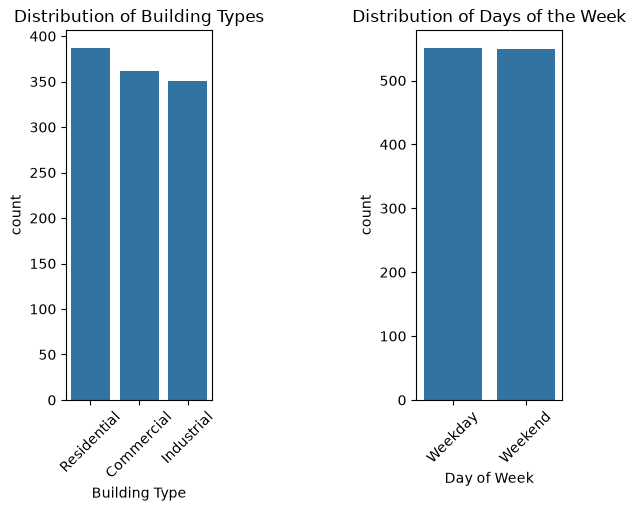

In [14]:
plt.subplot(1, 3, 1)
sns.countplot(x='Building Type', data=data)
plt.title('Distribution of Building Types')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.countplot(x='Day of Week', data=data)
plt.title('Distribution of Days of the Week')
plt.xticks(rotation=45)

(array([   0., 2000., 4000., 6000., 8000.]),
 [Text(0.0, 0, '0'),
  Text(2000.0, 0, '2000'),
  Text(4000.0, 0, '4000'),
  Text(6000.0, 0, '6000'),
  Text(8000.0, 0, '8000')])

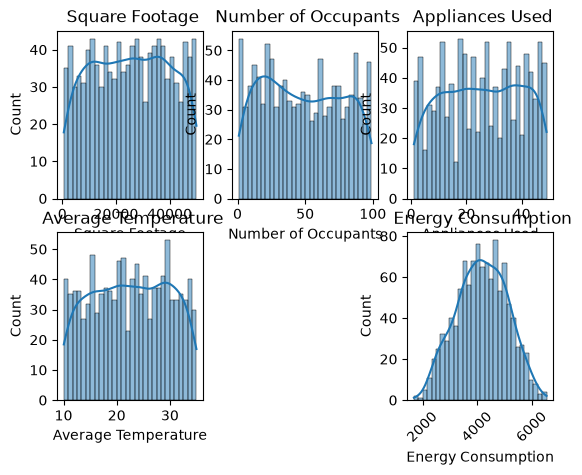

In [15]:
plt.subplot(2, 3, 1)
sns.histplot(data['Square Footage'], bins=30, kde=True)
plt.title(' Square Footage')


plt.subplot(2, 3, 2)
sns.histplot(data['Number of Occupants'], bins=30, kde=True)
plt.title(' Number of Occupants')

plt.subplot(2, 3, 3)
sns.histplot(data['Appliances Used'], bins=30, kde=True)
plt.title(' Appliances Used')

plt.subplot(2, 3, 4)
sns.histplot(data['Average Temperature'], bins=30, kde=True)
plt.title(' Average Temperature')

plt.subplot(2, 3, 6)
sns.histplot(data['Energy Consumption'], bins=30, kde=True)
plt.title(' Energy Consumption')
plt.xticks(rotation=45)

<Axes: ylabel='Energy Consumption'>

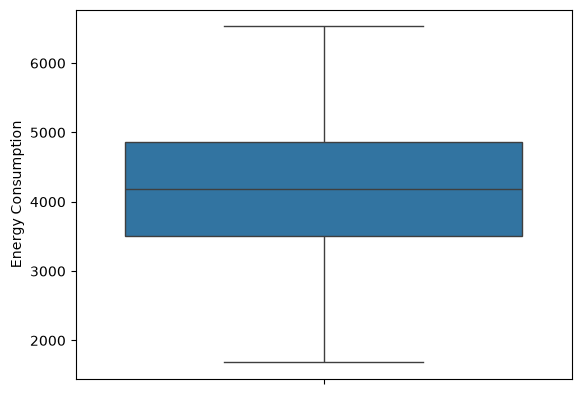

In [16]:
sns.boxplot(y='Energy Consumption', data=data)

.(bivariate and multivariate )Exploratory data analysis!!

In [17]:
data.head()

,Building Type,Square Footage,Number of Occupants,Appliances Used,Average Temperature,Day of Week,Energy Consumption
0,Residential,7063,76,10,29.84,Weekday,2713.95
1,Commercial,44372,66,45,16.72,Weekday,5744.99
2,Industrial,19255,37,17,14.30,Weekend,4101.24
3,Residential,13265,14,41,32.82,Weekday,3009.14
4,Commercial,13375,26,18,11.92,Weekday,3279.17
